# Run 3 Baselines on full_us weather data

Runs Persistence, Linear Regression, and LSTM next-hour temperature baselines after converting
`full_us.zip` into the same hourly table shape used by the original notebook.

Upload `full_us.zip`, `full_us_nodeList.csv`, `full_us_edgeList.csv`, and `full_us_stations.csv` in Colab, or keep them next to this notebook locally.
The notebook selects six geographically varied US spots by nearest available node:
Orlando, Seattle, Los Angeles, Denver, Chicago, and New York.

**LSTM upgrades in this version (vs first pass):**
1. Extra time features (`hour_sin/cos`, `doy_sin/cos`) so the LSTM doesn't have to re-discover the diurnal cycle.
2. Residual target: predict `next_temp - last_temp_in_window`, so the model focuses on what persistence gets wrong.
3. Early stopping with best-checkpoint restoration (patience = 5 val epochs).

**GPU is strongly recommended** (Runtime -> Change runtime type -> GPU).


In [ ]:
# ============================================================
# CELL 1: Imports
# ============================================================
import copy
import math
import os
import random
import re
import zipfile
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", DEVICE)


Using device: cuda


In [ ]:
# ============================================================
# CELL 2: Config
# ============================================================
SEED        = 42
LOOKBACK    = 24
TRAIN_RATIO = 0.80
VAL_RATIO   = 0.20
BATCH_SIZE  = 64
EPOCHS      = 50
PATIENCE    = 5
LR          = 1e-3
HIDDEN_SIZE = 64
NUM_LAYERS  = 1


FEATURES      = ["temperature", "humidity", "wind_u", "wind_v", "precipitation"]
TIME_FEATURES = ["hour_sin", "hour_cos", "doy_sin", "doy_cos"]
LSTM_FEATURES = FEATURES + TIME_FEATURES

TARGET_IDX = 0  # temperature

# New full-US dataset files
WEATHER_ZIP_PATH       = "full_us.zip"
WEATHER_EXTRACT_DIR    = "full_us"
NODELIST_CSV_PATH      = "full_us_nodeList.csv"
STATIONS_CSV_PATH      = "full_us_stations.csv"
EDGELIST_CSV_PATH      = "full_us_edgeList.csv"
ORGANIZED_CSV_PATH     = "full_us_hourly_organized_selected.csv"
REBUILD_FULL_US_CSV = False

SELECTED_TARGETS = [
    {"label": "Orlando, FL",    "latitude": 28.5383, "longitude": -81.3792},
    {"label": "Seattle, WA",    "latitude": 47.6062, "longitude": -122.3321},
    {"label": "Los Angeles, CA", "latitude": 34.0522, "longitude": -118.2437},
    {"label": "Denver, CO",     "latitude": 39.7392, "longitude": -104.9903},
    {"label": "Chicago, IL",    "latitude": 41.8781, "longitude": -87.6298},
    {"label": "New York, NY",   "latitude": 40.7128, "longitude": -74.0060},
]

CSV_PATH = ORGANIZED_CSV_PATH


def set_seed(seed=SEED):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

set_seed()


In [ ]:
# ============================================================
# CELL 3: Upload/extract full_us.zip + build organized CSV
#         Then load selected spots + derive wind/time features
# ============================================================
def maybe_upload_full_us_files():
    required_csvs = [NODELIST_CSV_PATH, STATIONS_CSV_PATH, EDGELIST_CSV_PATH]
    has_metadata = all(Path(p).exists() for p in required_csvs)
    has_zip = Path(WEATHER_ZIP_PATH).exists()
    has_extracted_weather = find_weather_root(WEATHER_EXTRACT_DIR) is not None
    if has_metadata and (has_zip or has_extracted_weather):
        return

    try:
        from google.colab import files
        print("Upload full_us.zip, full_us_nodeList.csv, full_us_edgeList.csv, and full_us_stations.csv when prompted.")
        files.upload()
    except Exception:
        print("Colab upload helper is unavailable here; looking for local files instead.")


def extract_weather_zip(zip_path=WEATHER_ZIP_PATH, extract_dir=WEATHER_EXTRACT_DIR):
    zip_path = Path(zip_path)
    extract_dir = Path(extract_dir)
    if find_weather_root(extract_dir) is not None:
        return
    if not zip_path.exists():
        return

    with zipfile.ZipFile(zip_path, "r") as zf:
        zf.extractall(".")
    print(f"Extracted {zip_path} -> {extract_dir}")


def find_weather_root(extract_dir=WEATHER_EXTRACT_DIR):
    extract_dir = Path(extract_dir)
    if not extract_dir.exists():
        return None

    required_files = {"temp_data.csv", "humidity_data.csv", "rain_data.csv", "wind_speed_data.csv"}
    for directory in [extract_dir, *extract_dir.rglob("*")]:
        if directory.is_dir() and required_files.issubset({p.name for p in directory.glob("*.csv")}):
            return directory.parent
    return None


def date_from_folder_name(folder_name):
    match = re.fullmatch(r"(\d{1,2})_(\d{1,2})_(\d{2,4})", folder_name)
    if not match:
        return None
    month, day, year = match.groups()
    year = int(year)
    if year < 100:
        year += 2000
    return pd.Timestamp(year=year, month=int(month), day=int(day))


def haversine_km(lat1, lon1, lat2, lon2):
    radius = 6371.0
    lat1, lon1, lat2, lon2 = map(np.deg2rad, [lat1, lon1, lat2, lon2])
    dlat = lat2 - lat1
    dlon = lon2 - lon1
    a = np.sin(dlat / 2) ** 2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon / 2) ** 2
    return 2 * radius * np.arctan2(np.sqrt(a), np.sqrt(1 - a))


def load_station_metadata():
    if not Path(NODELIST_CSV_PATH).exists():
        raise FileNotFoundError(f"Missing {NODELIST_CSV_PATH}. Upload it next to the notebook.")

    nodes = pd.read_csv(NODELIST_CSV_PATH)
    nodes["id"] = nodes["id"].astype(str)
    return nodes


def choose_selected_nodes(nodes):
    selected = []
    used_ids = set()

    for target in SELECTED_TARGETS:
        distances = haversine_km(
            target["latitude"],
            target["longitude"],
            nodes["latitude"].astype(float),
            nodes["longitude"].astype(float),
        )
        ranked = nodes.assign(distance_km=distances).sort_values("distance_km")
        row = ranked[~ranked["id"].isin(used_ids)].iloc[0].copy()
        used_ids.add(row["id"])
        row["target_label"] = target["label"]
        selected.append(row)

    selected_nodes = pd.DataFrame(selected)
    print("Selected spots mapped to nearest full_us nodes:")
    for _, row in selected_nodes.iterrows():
        print(
            f"  {row['target_label']}: node {row['id']} / {row['station_id']} - "
            f"{row['name']}, {row['region']} ({row['distance_km']:.1f} km away)"
        )
    return selected_nodes


def read_weather_measure(day_dir, filename, value_name, day, selected_ids):
    path = day_dir / filename
    if not path.exists():
        return None

    wide = pd.read_csv(path)
    id_col = "id" if "id" in wide.columns else "station"
    wide[id_col] = wide[id_col].astype(str)
    wide = wide[wide[id_col].isin(selected_ids)]
    if wide.empty:
        return None

    hour_cols = [c for c in wide.columns if c.startswith("hour_")]
    long = wide.melt(
        id_vars=id_col,
        value_vars=hour_cols,
        var_name="hour",
        value_name=value_name,
    )
    long["hour"] = long["hour"].str.extract(r"(\d+)").astype(int)
    long["timestamp"] = day + pd.to_timedelta(long["hour"], unit="h")
    long = long.rename(columns={id_col: "node_id"})
    return long[["timestamp", "node_id", value_name]]


def build_full_us_hourly_csv(selected_nodes, output_csv=ORGANIZED_CSV_PATH):
    maybe_upload_full_us_files()
    extract_weather_zip()

    output_csv = Path(output_csv)
    if output_csv.exists() and not REBUILD_FULL_US_CSV:
        print(f"Using existing organized CSV: {output_csv}")
        return str(output_csv)

    weather_root = find_weather_root()
    if weather_root is None:
        raise FileNotFoundError(f"Could not find {WEATHER_ZIP_PATH} or extracted {WEATHER_EXTRACT_DIR} weather folders.")

    selected_ids = set(selected_nodes["id"].astype(str))
    measure_files = {
        "temperature": "temp_data.csv",
        "humidity": "humidity_data.csv",
        "precipitation": "rain_data.csv",
        "wind_speed": "wind_speed_data.csv",
    }

    day_frames = []
    day_dirs = sorted([p for p in weather_root.iterdir() if p.is_dir()], key=lambda p: p.name)
    for day_dir in day_dirs:
        day = date_from_folder_name(day_dir.name)
        if day is None:
            continue

        merged = None
        for value_name, filename in measure_files.items():
            measure_df = read_weather_measure(day_dir, filename, value_name, day, selected_ids)
            if measure_df is None:
                continue
            if merged is None:
                merged = measure_df
            else:
                merged = merged.merge(measure_df, on=["timestamp", "node_id"], how="outer")

        if merged is not None:
            day_frames.append(merged)

    if not day_frames:
        raise ValueError(f"No selected node weather rows were found under {weather_root}.")

    organized = pd.concat(day_frames, ignore_index=True)
    selected_meta = selected_nodes[["id", "target_label", "station_id", "name", "region", "latitude", "longitude"]].copy()
    selected_meta = selected_meta.rename(columns={"id": "node_id"})
    selected_meta["node_id"] = selected_meta["node_id"].astype(str)

    organized = organized.merge(selected_meta, on="node_id", how="left")
    organized["city"] = organized["target_label"] + " (" + organized["name"] + ")"
    organized["wind_dir"] = np.nan  # full_us.zip has wind speed but not wind direction.
    organized = organized.sort_values(["city", "timestamp"]).reset_index(drop=True)
    organized = organized[
        [
            "timestamp", "city", "node_id", "station_id", "name", "region", "latitude", "longitude",
            "temperature", "humidity", "precipitation", "wind_speed", "wind_dir",
        ]
    ]
    organized.to_csv(output_csv, index=False)

    print(f"Saved {output_csv} with {len(organized):,} rows and {organized['city'].nunique():,} selected spots.")
    return str(output_csv)


nodes = load_station_metadata()
selected_nodes = choose_selected_nodes(nodes)
CSV_PATH = build_full_us_hourly_csv(selected_nodes)

df_all = pd.read_csv(CSV_PATH)
df_all["timestamp"] = pd.to_datetime(df_all["timestamp"])
df_all = df_all.sort_values(["city", "timestamp"]).reset_index(drop=True)

if "wind_dir" in df_all.columns and df_all["wind_dir"].notna().any():
    theta = np.deg2rad(df_all["wind_dir"])
    speed = df_all["wind_speed"]
    df_all["wind_u"] = -speed * np.sin(theta)
    df_all["wind_v"] = -speed * np.cos(theta)
else:
    df_all["wind_u"] = df_all["wind_speed"]
    df_all["wind_v"] = 0.0

# Cyclical time-of-day and time-of-year encodings for the LSTM
hour = df_all["timestamp"].dt.hour
doy  = df_all["timestamp"].dt.dayofyear
df_all["hour_sin"] = np.sin(2 * np.pi * hour / 24.0)
df_all["hour_cos"] = np.cos(2 * np.pi * hour / 24.0)
df_all["doy_sin"]  = np.sin(2 * np.pi * doy  / 365.25)
df_all["doy_cos"]  = np.cos(2 * np.pi * doy  / 365.25)

df_all = df_all.dropna(subset=FEATURES).reset_index(drop=True)

print(df_all[["city", "timestamp", *LSTM_FEATURES]].head())
print("\nRows per selected spot:")
print(df_all.groupby("city").size())


Selected spots mapped to nearest full_us nodes:
  Orlando, FL: node 2054 / KORL0 - Orlando / Azalea Park, FL (4.6 km away)
  Seattle, WA: node 1069 / KBFI0 - Seattle / South Park, WA (8.8 km away)
  Los Angeles, CA: node 1220 / KCQT0 - Los Angeles / Jefferson, CA (5.4 km away)
  Denver, CO: node 432 / 72469 - Denver / Stapleton International, Co., CO (11.6 km away)
  Chicago, IL: node 1177 / KCGX0 - Chicago / Central Station, IL (2.8 km away)
  New York, NY: node 1711 / KJRB0 - New York / Wall Street, NY (1.3 km away)
Extracted full_us.zip -> full_us
Saved full_us_hourly_organized_selected.csv with 52,560 rows and 6 selected spots.
                                      city           timestamp  temperature  \
0  Chicago, IL (Chicago / Central Station) 2018-01-01 00:00:00         4.46   
1  Chicago, IL (Chicago / Central Station) 2018-01-01 01:00:00         7.28   
2  Chicago, IL (Chicago / Central Station) 2018-01-01 02:00:00         5.66   
3  Chicago, IL (Chicago / Central Station) 2

In [ ]:
# ============================================================
# CELL 4: Shared preprocessing + sequence builder
# ============================================================
def preprocess_city(city_df, feature_cols):
    data = city_df[feature_cols].values.astype(np.float32)
    ts   = city_df["timestamp"].values

    split_idx = int(len(data) * TRAIN_RATIO)
    train_data, test_data = data[:split_idx], data[split_idx:]
    train_ts,   test_ts   = ts[:split_idx],   ts[split_idx:]

    mean = train_data.mean(axis=0)
    std  = train_data.std(axis=0)
    std[std == 0] = 1.0

    train_scaled = (train_data - mean) / std
    test_scaled  = (test_data  - mean) / std

    return train_scaled, test_scaled, train_ts, test_ts, mean, std


def create_sequences(data_scaled, ts, lookback=LOOKBACK):
    X, y, y_ts = [], [], []
    for i in range(lookback, len(data_scaled)):
        X.append(data_scaled[i - lookback:i])
        y.append(data_scaled[i][TARGET_IDX])
        y_ts.append(ts[i])
    X = np.asarray(X, dtype=np.float32)
    y = np.asarray(y, dtype=np.float32).reshape(-1, 1)
    return X, y, np.asarray(y_ts)

In [ ]:
# ============================================================
# CELL 5: Model 1 - Persistence
# ============================================================
def run_persistence(X_test, y_test, mean, std):
    preds = X_test[:, -1, TARGET_IDX].reshape(-1, 1)
    preds_unscaled  = preds  * std[TARGET_IDX] + mean[TARGET_IDX]
    y_true_unscaled = y_test * std[TARGET_IDX] + mean[TARGET_IDX]

    mae  = mean_absolute_error(y_true_unscaled, preds_unscaled)
    rmse = math.sqrt(mean_squared_error(y_true_unscaled, preds_unscaled))
    return {"mae": mae, "rmse": rmse, "preds": preds_unscaled, "truth": y_true_unscaled}

In [ ]:
# ============================================================
# CELL 6: Model 2 - Linear Regression on the flattened window
# ============================================================
def run_linreg(X_train, y_train, X_test, y_test, mean, std):
    X_train_flat = X_train.reshape(X_train.shape[0], -1)
    X_test_flat  = X_test.reshape(X_test.shape[0], -1)

    model = LinearRegression()
    model.fit(X_train_flat, y_train.ravel())
    preds = model.predict(X_test_flat).reshape(-1, 1)

    preds_unscaled  = preds  * std[TARGET_IDX] + mean[TARGET_IDX]
    y_true_unscaled = y_test * std[TARGET_IDX] + mean[TARGET_IDX]

    mae  = mean_absolute_error(y_true_unscaled, preds_unscaled)
    rmse = math.sqrt(mean_squared_error(y_true_unscaled, preds_unscaled))
    return {"mae": mae, "rmse": rmse, "preds": preds_unscaled, "truth": y_true_unscaled}

In [ ]:
# ============================================================
# CELL 7: Model 3 - LSTM v2
#   - 9 input features (5 weather + 4 time encodings)
#   - residual target: y - last_temp_in_window
#   - early stopping on val loss, restore best weights
# ============================================================
class WeatherDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.float32)
    def __len__(self):         return len(self.X)
    def __getitem__(self, i):  return self.X[i], self.y[i]


class LSTMRegressor(nn.Module):
    def __init__(self, input_size, hidden_size=HIDDEN_SIZE, num_layers=NUM_LAYERS):
        super().__init__()
        self.lstm = nn.LSTM(input_size, hidden_size, num_layers, batch_first=True)
        self.fc   = nn.Linear(hidden_size, 1)
    def forward(self, x):
        _, (h_n, _) = self.lstm(x)
        return self.fc(h_n[-1])


def run_lstm(X_train_full, y_train_full, X_test, y_test, mean, std, verbose=False):
    set_seed()


    last_temp_train_full = X_train_full[:, -1, TARGET_IDX].reshape(-1, 1)
    last_temp_test       = X_test[:, -1, TARGET_IDX].reshape(-1, 1)
    y_train_full_res     = (y_train_full - last_temp_train_full).astype(np.float32)


    val_start = int(len(X_train_full) * (1 - VAL_RATIO))
    X_train, y_train_res = X_train_full[:val_start], y_train_full_res[:val_start]
    X_val,   y_val_res   = X_train_full[val_start:], y_train_full_res[val_start:]

    train_loader = DataLoader(WeatherDataset(X_train, y_train_res), batch_size=BATCH_SIZE, shuffle=False)
    val_loader   = DataLoader(WeatherDataset(X_val,   y_val_res),   batch_size=BATCH_SIZE, shuffle=False)
    test_loader  = DataLoader(WeatherDataset(X_test,  y_test),      batch_size=BATCH_SIZE, shuffle=False)  # y_test

    model     = LSTMRegressor(input_size=X_train.shape[2]).to(DEVICE)
    criterion = nn.MSELoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=LR)

    train_losses, val_losses = [], []
    best_val_loss = float("inf")
    best_state    = None
    best_epoch    = 0
    epochs_no_improve = 0

    for epoch in range(1, EPOCHS + 1):
        # --- train ---
        model.train()
        total = 0.0
        for Xb, yb in train_loader:
            Xb, yb = Xb.to(DEVICE), yb.to(DEVICE)
            optimizer.zero_grad()
            loss = criterion(model(Xb), yb)
            loss.backward()
            optimizer.step()
            total += loss.item() * Xb.size(0)
        train_losses.append(total / len(train_loader.dataset))

        # --- validate ---
        model.eval()
        total = 0.0
        with torch.no_grad():
            for Xb, yb in val_loader:
                Xb, yb = Xb.to(DEVICE), yb.to(DEVICE)
                total += criterion(model(Xb), yb).item() * Xb.size(0)
        val_loss = total / len(val_loader.dataset)
        val_losses.append(val_loss)

        # --- early stopping ---
        if val_loss < best_val_loss - 1e-6:
            best_val_loss     = val_loss
            best_state        = copy.deepcopy(model.state_dict())
            best_epoch        = epoch
            epochs_no_improve = 0
        else:
            epochs_no_improve += 1

        if verbose:
            flag = "*" if epoch == best_epoch else " "
            print(f"  epoch {epoch:02d}{flag}  train={train_losses[-1]:.5f}  val={val_losses[-1]:.5f}")

        if epochs_no_improve >= PATIENCE:
            break

    # Restore the best weights before testing
    if best_state is not None:
        model.load_state_dict(best_state)

    # --- predict on test set ---
    model.eval()
    preds_chunks = []
    with torch.no_grad():
        for Xb, _ in test_loader:
            preds_chunks.append(model(Xb.to(DEVICE)).cpu().numpy())
    preds_residual = np.vstack(preds_chunks)

    # Undo the residual parameterization, then unscale to degrees C
    preds_scaled    = preds_residual + last_temp_test
    preds_unscaled  = preds_scaled * std[TARGET_IDX] + mean[TARGET_IDX]
    y_true_unscaled = y_test       * std[TARGET_IDX] + mean[TARGET_IDX]

    mae  = mean_absolute_error(y_true_unscaled, preds_unscaled)
    rmse = math.sqrt(mean_squared_error(y_true_unscaled, preds_unscaled))

    return {
        "mae": mae, "rmse": rmse,
        "preds": preds_unscaled, "truth": y_true_unscaled,
        "train_losses": train_losses, "val_losses": val_losses,
        "best_epoch": best_epoch, "epochs_run": len(train_losses),
    }

In [ ]:
# ============================================================
# CELL 8: Main loop - run all 3 models for every city
# Persistence + LinReg use the 5 base features.
# LSTM uses the 9-feature extended set (base + time features).
# ============================================================
results_rows  = []
city_outputs  = {}

for city, city_df in df_all.groupby("city", sort=False):
    print(f"\n========== {city}  (rows={len(city_df):,}) ==========")

    # --- Baseline features (5) for persistence + linreg ---
    tr_s, te_s, tr_ts, te_ts, mean, std = preprocess_city(city_df, FEATURES)
    X_train, y_train, _        = create_sequences(tr_s, tr_ts)
    X_test,  y_test,  y_test_ts = create_sequences(te_s, te_ts)

    pers = run_persistence(X_test, y_test, mean, std)
    print(f"Persistence       MAE={pers['mae']:.4f}  RMSE={pers['rmse']:.4f}")

    lr = run_linreg(X_train, y_train, X_test, y_test, mean, std)
    print(f"LinearRegression  MAE={lr['mae']:.4f}  RMSE={lr['rmse']:.4f}")

    # --- Extended features (9) for LSTM ---
    tr_sL, te_sL, tr_tsL, te_tsL, meanL, stdL = preprocess_city(city_df, LSTM_FEATURES)
    X_trainL, y_trainL, _ = create_sequences(tr_sL, tr_tsL)
    X_testL,  y_testL, _  = create_sequences(te_sL, te_tsL)

    lstm = run_lstm(X_trainL, y_trainL, X_testL, y_testL, meanL, stdL, verbose=False)
    print(f"LSTM              MAE={lstm['mae']:.4f}  RMSE={lstm['rmse']:.4f}   "
          f"(best epoch {lstm['best_epoch']} / {lstm['epochs_run']} run)")

    for name, res in [("Persistence", pers), ("LinearRegression", lr), ("LSTM", lstm)]:
        results_rows.append({"city": city, "model": name, "MAE": res["mae"], "RMSE": res["rmse"]})

    city_outputs[city] = {
        "y_test_ts": y_test_ts,
        "truth":     pers["truth"],
        "pers":      pers["preds"],
        "lr":        lr["preds"],
        "lstm":      lstm["preds"],
        "lstm_train_losses": lstm["train_losses"],
        "lstm_val_losses":   lstm["val_losses"],
        "lstm_best_epoch":   lstm["best_epoch"],
    }


========== Chicago, IL (Chicago / Central Station)  (rows=8,760) ==========
Persistence       MAE=0.8918  RMSE=1.2445
LinearRegression  MAE=0.6602  RMSE=0.8940
LSTM              MAE=0.7877  RMSE=1.0117   (best epoch 7 / 12 run)

========== Denver, CO (Denver / Stapleton International, Co.)  (rows=8,760) ==========
Persistence       MAE=1.6669  RMSE=2.1680
LinearRegression  MAE=1.2856  RMSE=1.6478
LSTM              MAE=1.1363  RMSE=1.4883   (best epoch 10 / 15 run)

========== Los Angeles, CA (Los Angeles / Jefferson)  (rows=8,760) ==========
Persistence       MAE=1.4641  RMSE=1.9305
LinearRegression  MAE=0.8379  RMSE=1.1259
LSTM              MAE=0.7700  RMSE=1.0203   (best epoch 11 / 16 run)

========== New York, NY (New York / Wall Street)  (rows=8,760) ==========
Persistence       MAE=0.9300  RMSE=1.3552
LinearRegression  MAE=0.8697  RMSE=1.2198
LSTM              MAE=0.8256  RMSE=1.1443   (best epoch 7 / 12 run)

========== Orlando, FL (Orlando / Azalea Park)  (rows=8,760) =========

In [ ]:
# ============================================================
# CELL 9: Results summary
# ============================================================
results_df = pd.DataFrame(results_rows)

print("\n--- Long format ---")
print(results_df.round(4).to_string(index=False))

print("\n--- Wide format (MAE) ---")
mae_pivot = results_df.pivot(index="city", columns="model", values="MAE").round(4)
print(mae_pivot)

print("\n--- Wide format (RMSE) ---")
rmse_pivot = results_df.pivot(index="city", columns="model", values="RMSE").round(4)
print(rmse_pivot)

# % improvement over persistence, for quick scanning
pers_mae = mae_pivot["Persistence"]
improvement = pd.DataFrame({
    "LinReg_%gain_vs_Pers": (1 - mae_pivot["LinearRegression"] / pers_mae) * 100,
    "LSTM_%gain_vs_Pers":   (1 - mae_pivot["LSTM"]             / pers_mae) * 100,
}).round(1)
print("\n--- % MAE reduction vs Persistence ---")
print(improvement)

results_df.to_csv("baseline_results_all_cities.csv", index=False)
print("\nSaved baseline_results_all_cities.csv")


--- Long format ---
                                              city            model    MAE   RMSE
           Chicago, IL (Chicago / Central Station)      Persistence 0.8918 1.2445
           Chicago, IL (Chicago / Central Station) LinearRegression 0.6602 0.8940
           Chicago, IL (Chicago / Central Station)             LSTM 0.7877 1.0117
Denver, CO (Denver / Stapleton International, Co.)      Persistence 1.6669 2.1680
Denver, CO (Denver / Stapleton International, Co.) LinearRegression 1.2856 1.6478
Denver, CO (Denver / Stapleton International, Co.)             LSTM 1.1363 1.4883
         Los Angeles, CA (Los Angeles / Jefferson)      Persistence 1.4641 1.9305
         Los Angeles, CA (Los Angeles / Jefferson) LinearRegression 0.8379 1.1259
         Los Angeles, CA (Los Angeles / Jefferson)             LSTM 0.7700 1.0203
             New York, NY (New York / Wall Street)      Persistence 0.9300 1.3552
             New York, NY (New York / Wall Street) LinearRegression 0.8697 1.

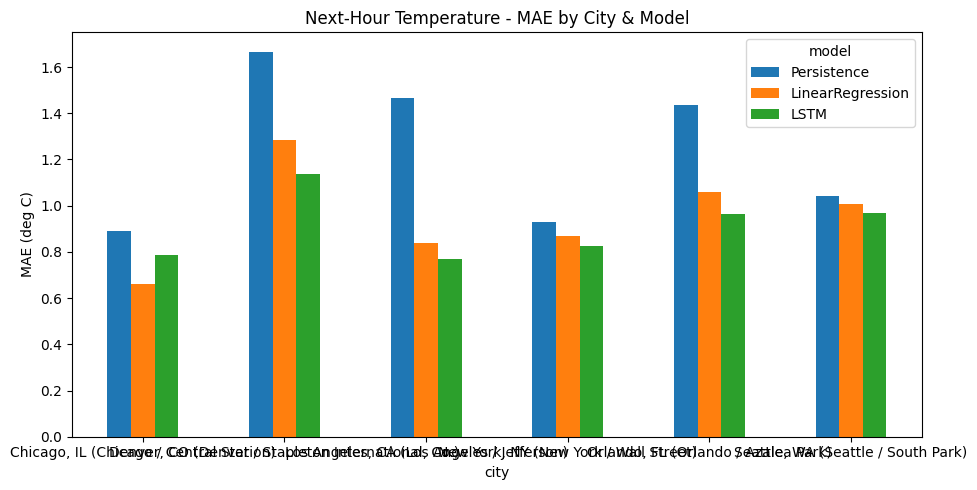

In [ ]:
# ============================================================
# CELL 10: Bar chart - MAE per city per model
# ============================================================
ax = mae_pivot[["Persistence", "LinearRegression", "LSTM"]].plot(
    kind="bar", figsize=(10, 5), rot=0
)
ax.set_ylabel("MAE (deg C)")
ax.set_title("Next-Hour Temperature - MAE by City & Model")
plt.tight_layout()
plt.show()

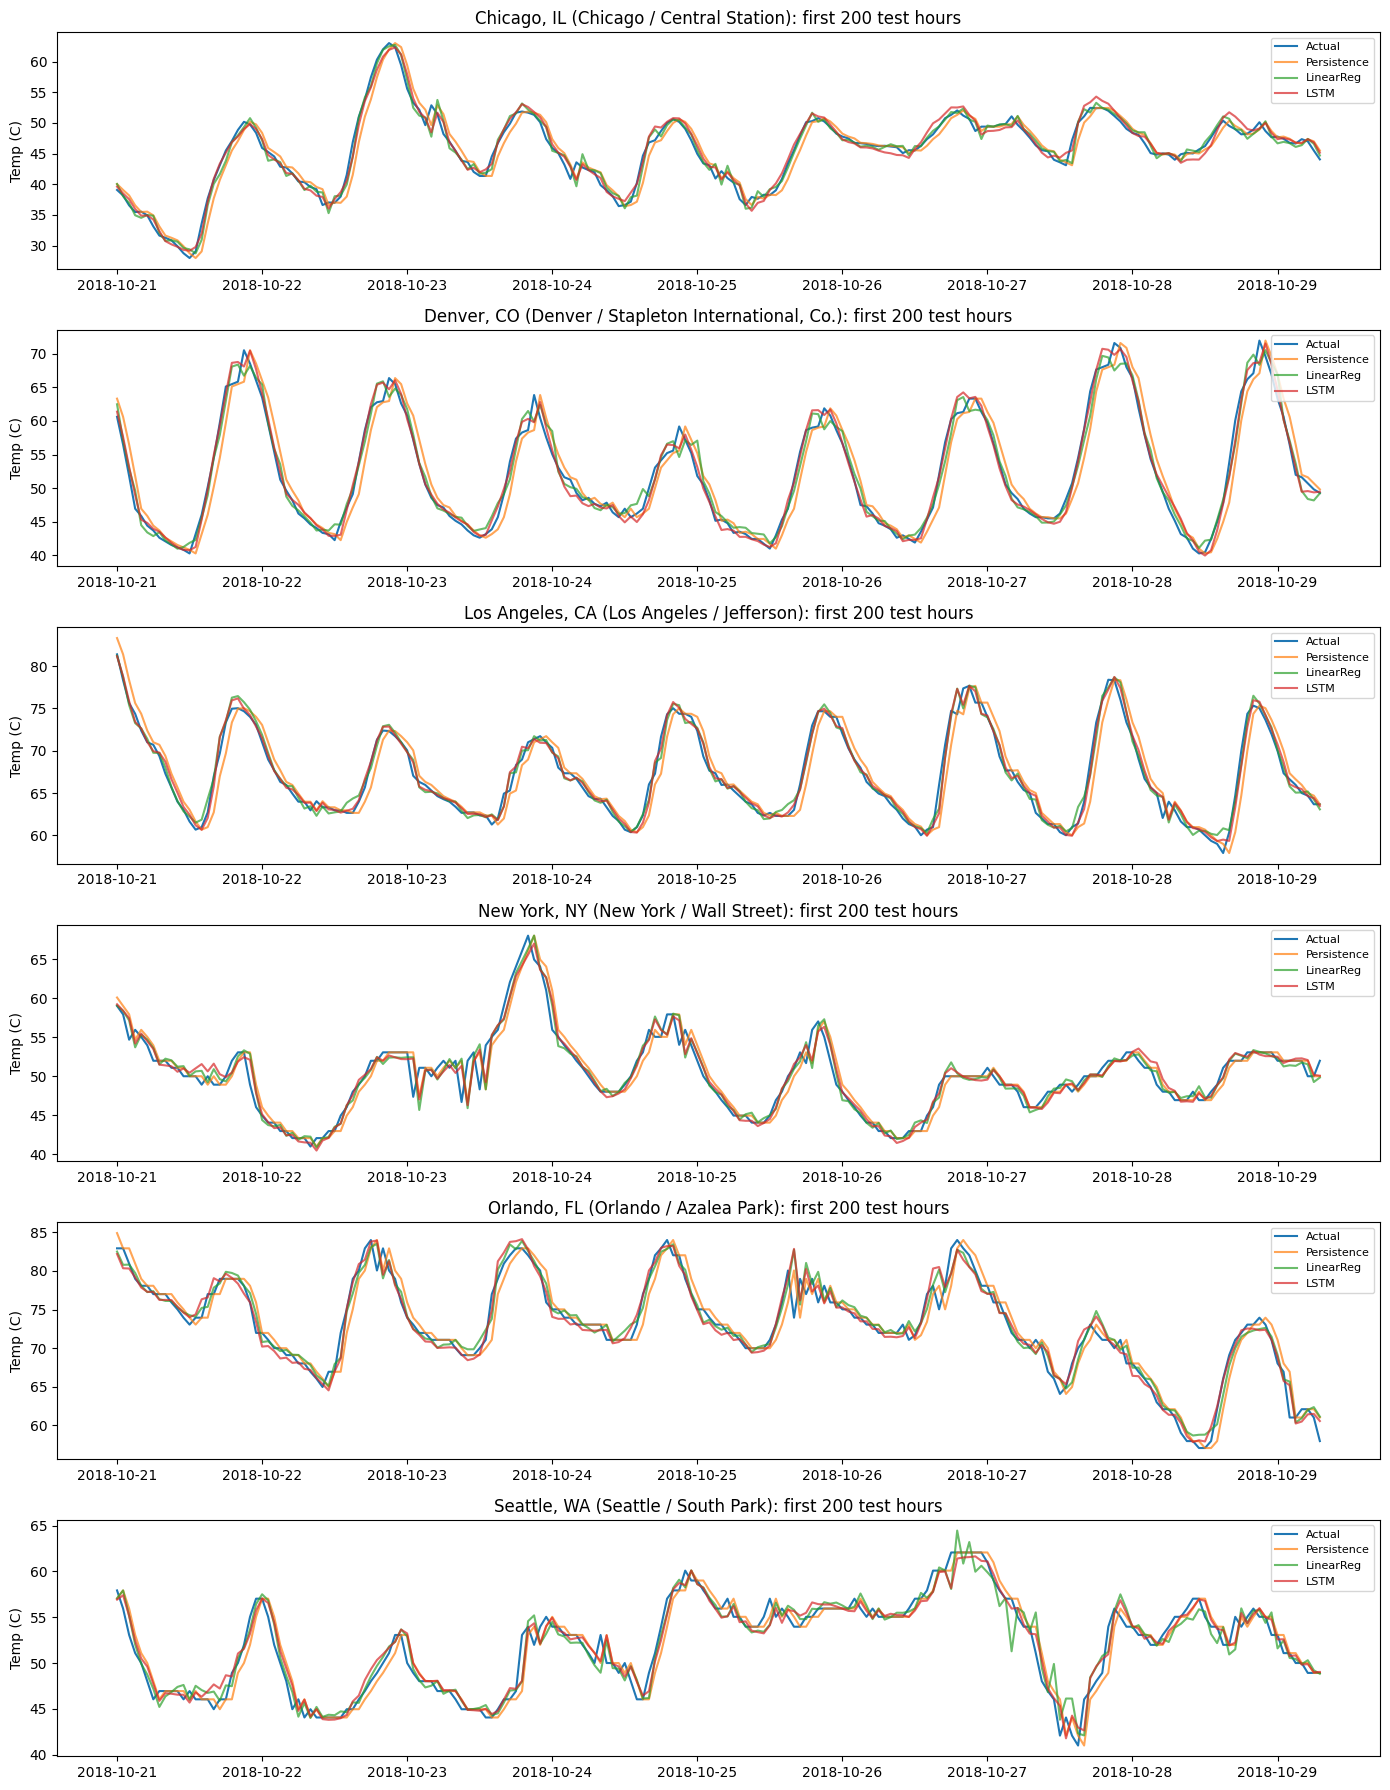

In [ ]:
# ============================================================
# CELL 11: Per-city prediction plots (first 200 test hours)
# ============================================================
cities = list(city_outputs.keys())
fig, axes = plt.subplots(len(cities), 1, figsize=(14, 3 * len(cities)), sharex=False)

for ax, city in zip(axes, cities):
    o = city_outputs[city]
    n = min(200, len(o["truth"]))
    ax.plot(o["y_test_ts"][:n], o["truth"][:n], label="Actual",      linewidth=1.5)
    ax.plot(o["y_test_ts"][:n], o["pers"][:n],  label="Persistence", alpha=0.7)
    ax.plot(o["y_test_ts"][:n], o["lr"][:n],    label="LinearReg",   alpha=0.7)
    ax.plot(o["y_test_ts"][:n], o["lstm"][:n],  label="LSTM",        alpha=0.7)
    ax.set_title(f"{city}: first {n} test hours")
    ax.set_ylabel("Temp (C)")
    ax.legend(loc="upper right", fontsize=8)

plt.tight_layout()
plt.show()

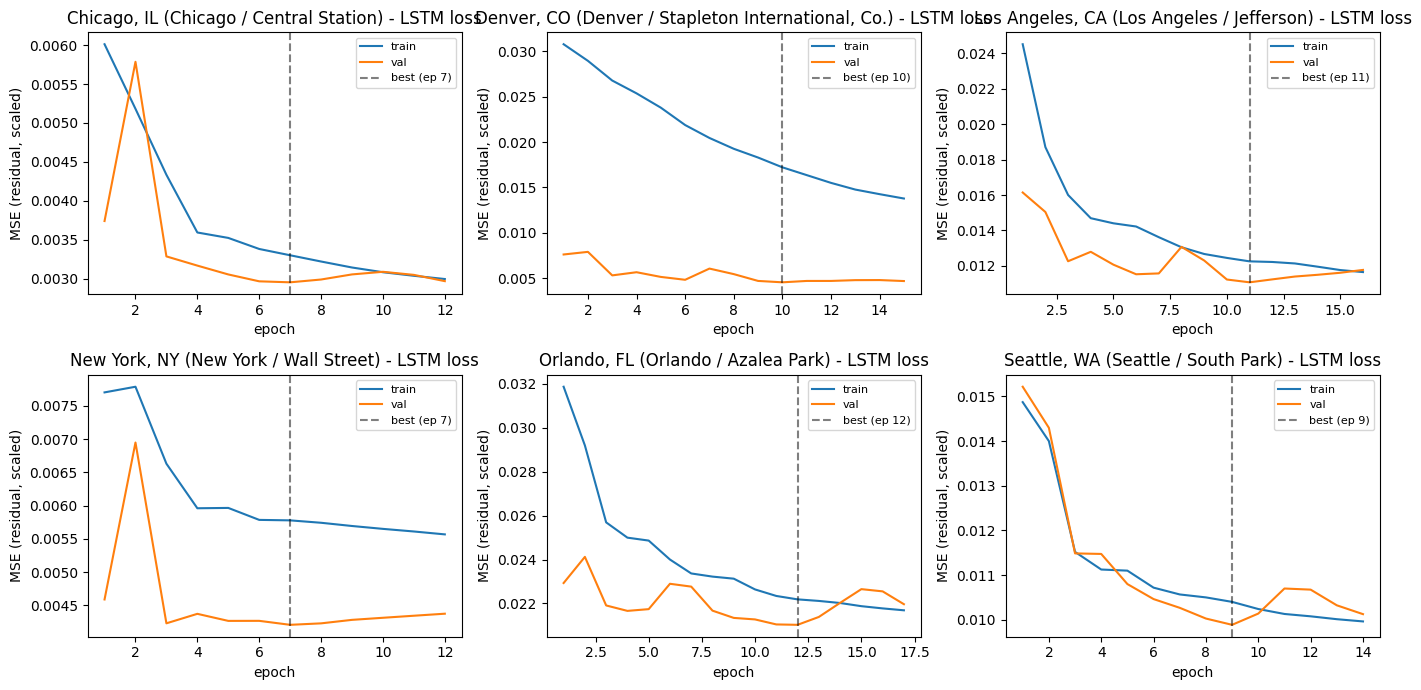

In [ ]:
# ============================================================
# CELL 12: LSTM loss curves + best-epoch marker per city
# ============================================================
fig, axes = plt.subplots(2, 3, figsize=(14, 7), sharex=False)
for ax, city in zip(axes.flatten(), cities):
    o = city_outputs[city]
    epochs = range(1, len(o["lstm_train_losses"]) + 1)
    ax.plot(epochs, o["lstm_train_losses"], label="train")
    ax.plot(epochs, o["lstm_val_losses"],   label="val")
    ax.axvline(o["lstm_best_epoch"], color="k", linestyle="--", alpha=0.5,
               label=f"best (ep {o['lstm_best_epoch']})")
    ax.set_title(f"{city} - LSTM loss")
    ax.set_xlabel("epoch")
    ax.set_ylabel("MSE (residual, scaled)")
    ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

In [ ]:
# ============================================================
# CELL 13: (Optional) Download results from Colab
# ============================================================
# from google.colab import files
# files.download("baseline_results_all_cities.csv")